In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
%matplotlib inline


In [81]:
df=pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [82]:
df.shape

(1000, 9)

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [84]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [85]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [86]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.drop_duplicates(inplace=True)

In [89]:
df["Date"]=pd.to_datetime(df["Date"])

In [90]:
df["Month"]=df["Date"].dt.month_name()
df["Quarter"]=df["Date"].dt.quarter

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   str           
 10  Quarter           1000 non-null   int32         
dtypes: datetime64[us](1), int32(1), int64(5), str(4)
memory usage: 82.2 KB


In [92]:
df.mean(numeric_only=True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
Quarter             2.525
dtype: float64

In [93]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
Quarter             2.0
dtype: float64

In [94]:
df.mode()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-05-16,CUST001,Female,43.0,Clothing,4.0,50.0,50.0,May,2.0
1,2,NaT,CUST002,NaN,64.0,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaT,CUST003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaT,CUST004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaT,CUST005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
995,996,NaT,CUST995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,997,NaT,CUST996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,998,NaT,CUST997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,999,NaT,CUST998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
Quarter             1.119208
dtype: float64

In [96]:
print("Total Revenue =",df["Total Amount"].sum())

Total Revenue = 456000


In [97]:
print(df["Total Amount"].mean())

456.0


In [98]:
monthly_sales=df.groupby("Month")["Total Amount"].sum()
monthly_sales

Month
April        33870
August       36960
December     44690
February     44060
January      36980
July         35465
June         36715
March        28990
May          53150
November     34920
October      46580
September    23620
Name: Total Amount, dtype: int64

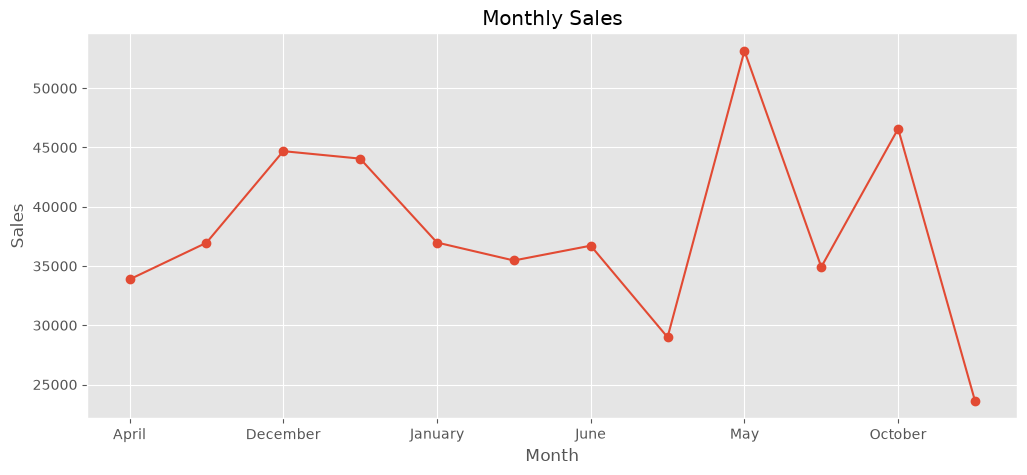

In [99]:
monthly_sales.plot(figsize=(12,5),marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

-Sales fluctuate across different months,indicating seasonal demand.
-According to the above graph the sales has gradually increased in the month of May.
-Businesses should plan inventory and promotions based on high-sales months.

In [100]:
quarter_sales=df.groupby("Quarter")["Total Amount"].sum()
quarter_sales

Quarter
1    110030
2    123735
3     96045
4    126190
Name: Total Amount, dtype: int64

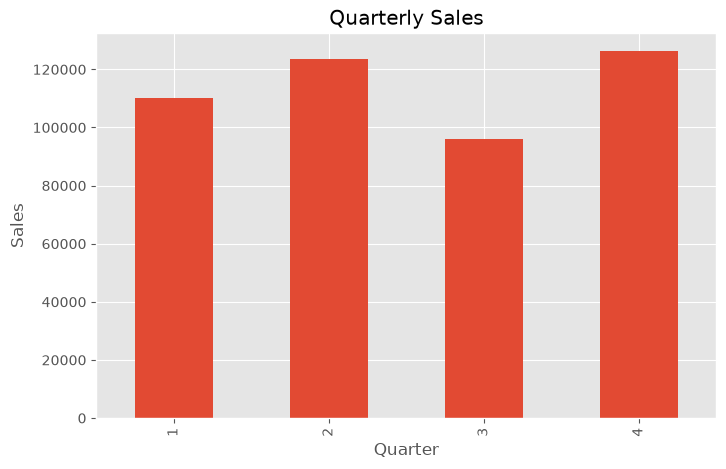

In [101]:
quarter_sales.plot(kind="bar",figsize=(8,5))
plt.title("Quarterly Sales")
plt.ylabel("Sales")
plt.show()

-According to the bar chart quarter-2 & quarter-4 has highest no.of sales.

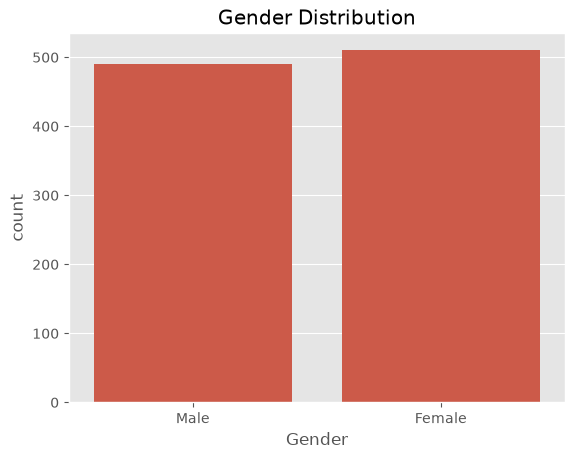

In [102]:
sns.countplot(data=df,x="Gender")
plt.title("Gender Distribution")
plt.show()

-According to the graph female customers are slightly higher than the male customers.
-Businesses should try to increase the products related to females.

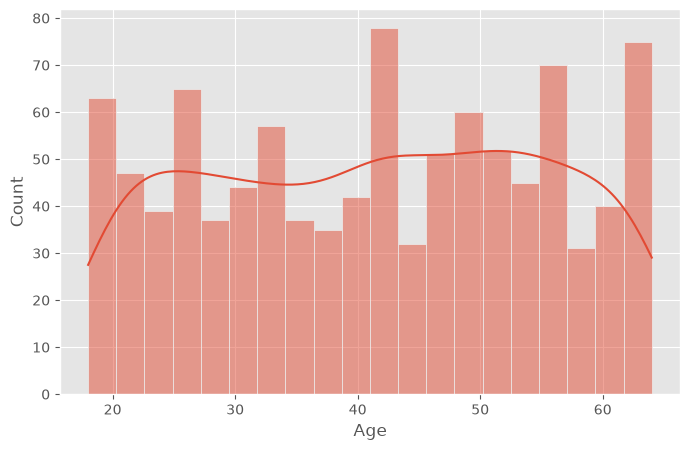

In [103]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"],bins=20,kde=True)
plt.show()

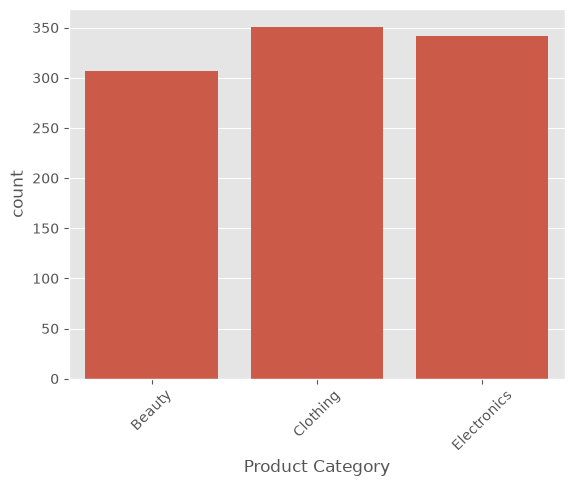

In [104]:
sns.countplot(data=df,x="Product Category")
plt.xticks(rotation=45)
plt.show()

In [105]:
category=df.groupby("Product Category")["Total Amount"].sum()
category

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

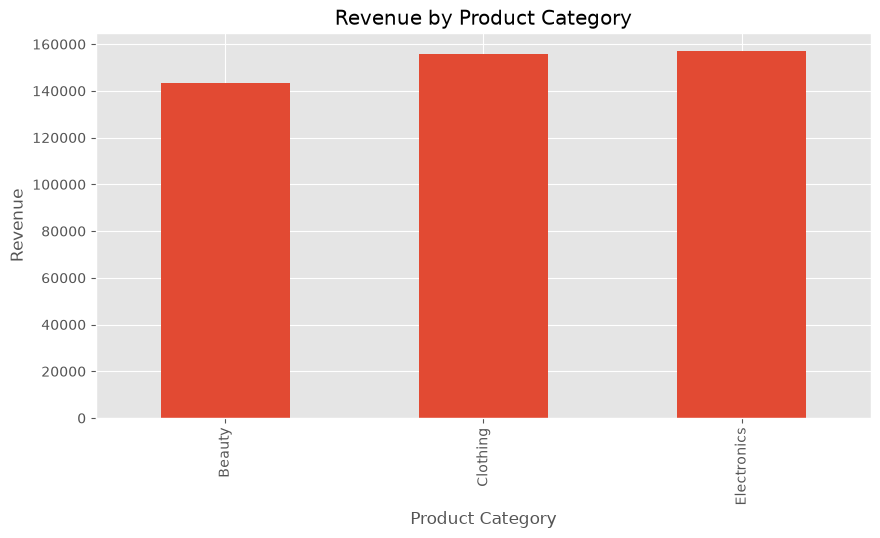

In [106]:
category.plot(kind="bar",figsize=(10,5))
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()

-According to the graph clothing and Electronics has highest revenue compared to beauty.

In [107]:
import pandas as pd
import numpy as np            
import matplotlib.pyplot as plt         
import seaborn as sns    
plt.style.use("ggplot")
%matplotlib inline                    

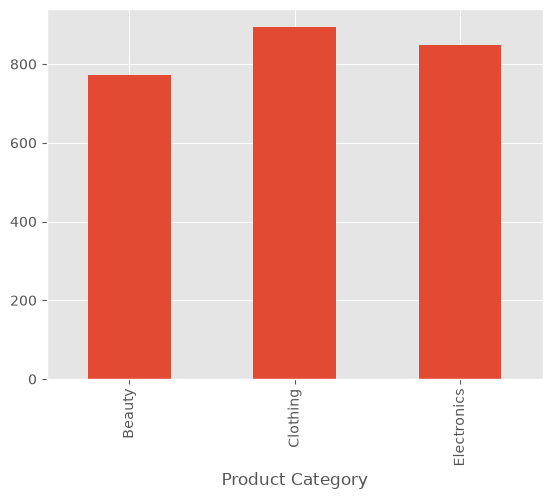

In [108]:
quantity=df.groupby("Product Category")["Quantity"].sum()
quantity.plot(kind="bar")
plt.show()

-According to the graph Clothing and Electronics has highest no.of sales compared to the beauty products.

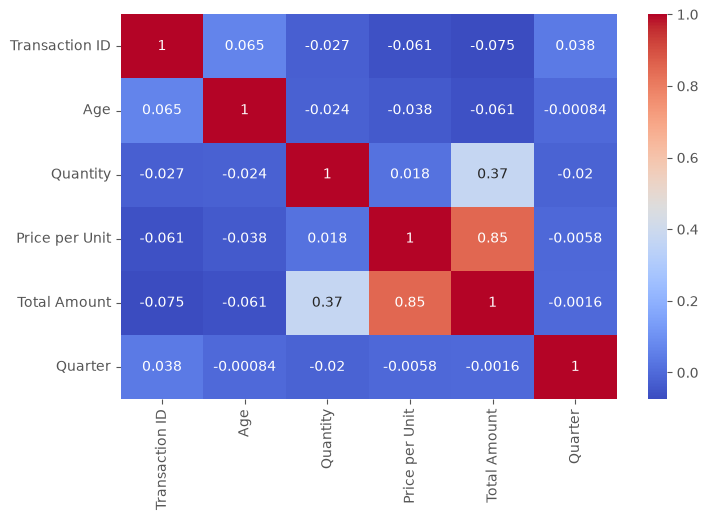

In [109]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

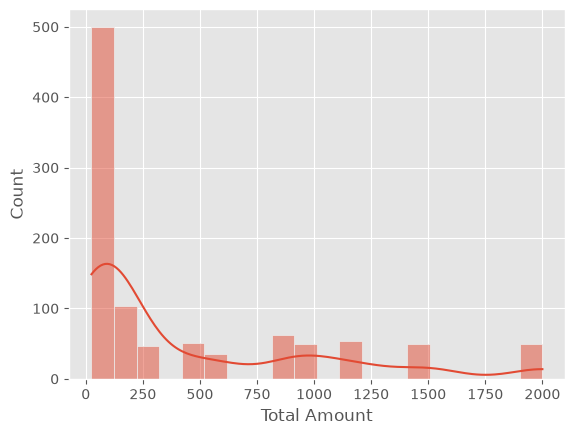

In [110]:
sns.histplot(df["Total Amount"],bins=20,kde=True)
plt.show()

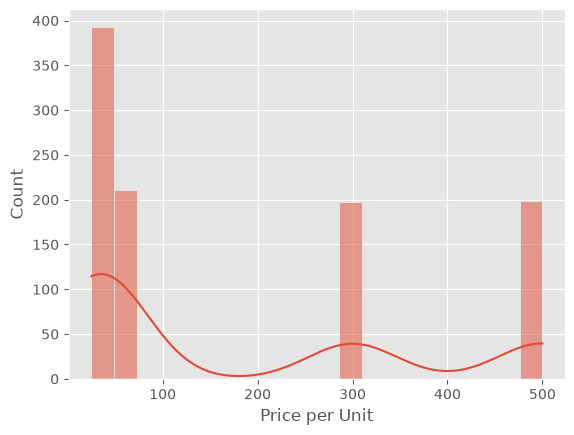

In [111]:
sns.histplot(df["Price per Unit"],bins=20,kde=True)
plt.show()

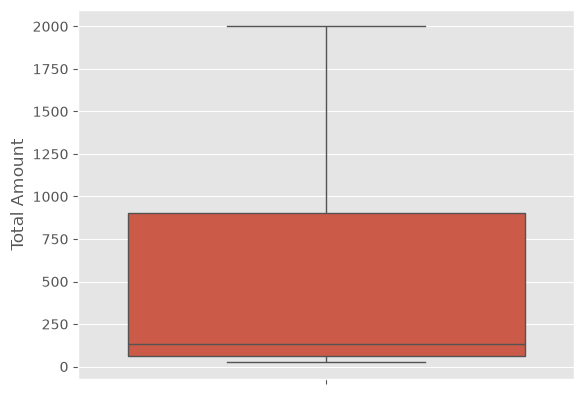

In [112]:
sns.boxplot(y=df["Total Amount"])
plt.show()

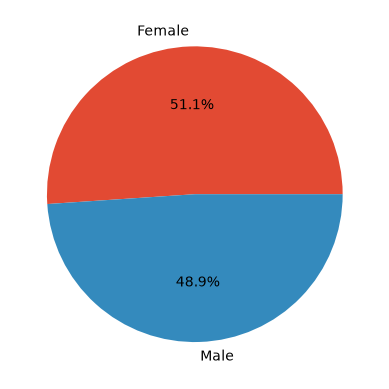

In [113]:
gender=df.groupby("Gender")["Total Amount"].sum()
gender.plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.show()

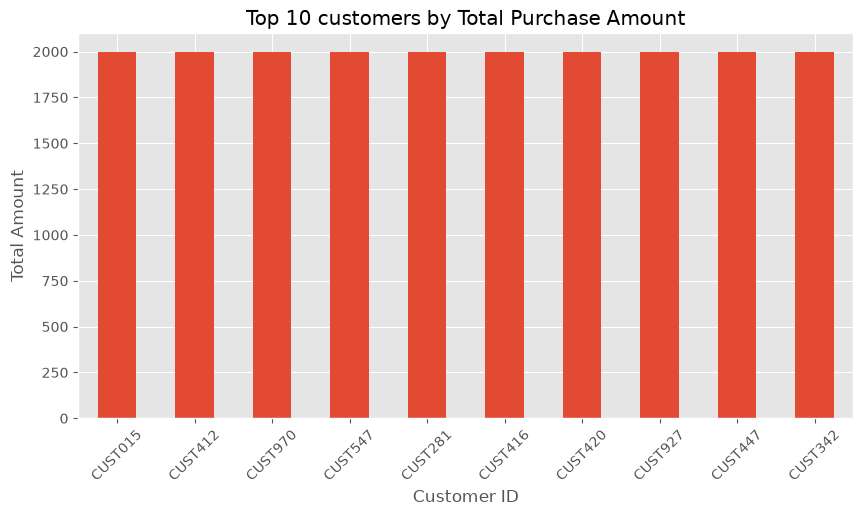

In [114]:
top=df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False).head(10)
top.plot(kind="bar",
figsize=(10,5))
plt.title("Top 10 customers by Total Purchase Amount")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

The above graph shows the Top 10 customers by total amount.

In [115]:
print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Quarter'],
      dtype='str')


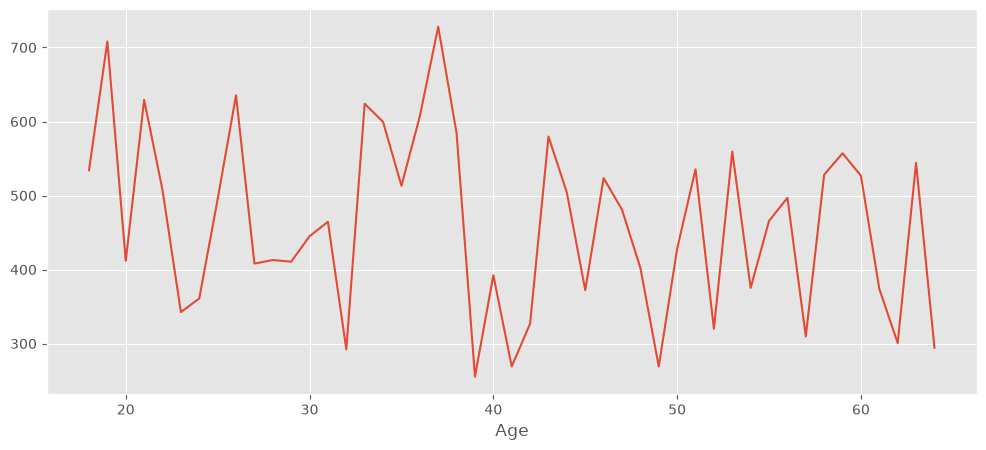

In [116]:
age=df.groupby("Age")["Total Amount"].mean()
age.plot(figsize=(12,5))
plt.show()

According the analysis between 30 to 40 age group has maximum number of sales .

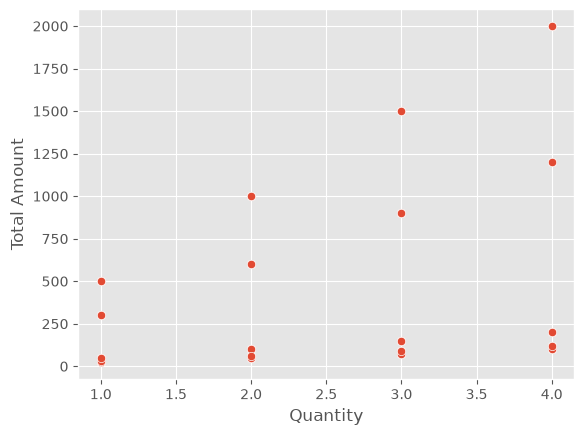

In [117]:
sns.scatterplot(data=df,x="Quantity",y="Total Amount")
plt.show()

In [118]:
df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False).head()

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

Electronics category has maximum revenue.

In [119]:
print("Business Insights")
print("1.Electronics products has maximum revenue")
print("2.Female customers has highest no.of sales")
print("3.According the analysis quarter-2 and quarter-4 has maximum sales.")
print("4.According to the above analysis total amount is increased for more no.of quantity.")
print("5.Beauty products is recommended promotional strategies to improve the sales.")

Business Insights
1.Electronics products has maximum revenue
2.Female customers has highest no.of sales
3.According the analysis quarter-2 and quarter-4 has maximum sales.
4.According to the above analysis total amount is increased for more no.of quantity.
5.Beauty products is recommended promotional strategies to improve the sales.


In [120]:
print("Conclusion")
print("Retail sales analysis reveals customer purchasing patterns,seasonal trends,and category performance,Business can use these inventory,improve marketing strategies,and increase overall revenue")

Conclusion
Retail sales analysis reveals customer purchasing patterns,seasonal trends,and category performance,Business can use these inventory,improve marketing strategies,and increase overall revenue
